# Задержки вылетов рейсов США, январь–июнь 2026

## 1. Бизнес-постановка и управление проектом

**ML-задача:** бинарная классификация. Объект — запланированный рейс, целевая переменная — `DepDel15`: задержится ли вылет на 15 минут и больше (1 — да, 0 — нет).
Признаки — только то, что известно до вылета: дата, время по расписанию, авиакомпания, аэропорты и штаты вылета и прилёта, дистанция, время в пути по расписанию.
Всё, что становится известно после вылета (фактическое время, руление, прилёт, причины задержки), в признаки не берём — это утечка ответа.

Задержанных рейсов около четверти, поэтому accuracy будет обманчивой: константа «не задержится» угадывает ~77%. Метрики для обучения на следующей паре — ROC-AUC и PR-AUC.

**Распределение задач по CRISP-DM:**

| Этап CRISP-DM | Задачи | Роль | Участник |
|---|---|---|---|
| Business Understanding | формулировка ML-задачи, выбор целевой переменной и метрик | Руководитель | |
| Data Understanding | выбор датасета, аудит размерности и структуры, описание колонок | Руководитель / Аналитик | |
| Data Understanding (EDA) | графики, анализ связи признаков с таргетом, выводы | Аналитик | |
| Data Preparation | поиск дефектов, пропуски, удаление признаков, фильтрация аномалий | Инженер данных | |
| Data Preparation (экспорт) | проверка отсутствия пропусков, сохранение очищенной таблицы в CSV | ML-инженер | |
| Modeling / Evaluation | обучение и сравнение моделей (следующая пара) | ML-инженер | |

In [1]:
%pip install -q pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Iaroslav\AppData\Local\Temp\claude\C--Users-Iaroslav-Desktop--------ForkIT----------------v2\4f485f0d-e3d3-4c1f-874f-c70487cdeebc\scratchpad\nbenv\Scripts\python.exe -m pip install --upgrade pip


In [2]:
import glob, zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Аудит и описание данных

**Источник:**

Данные — отчётность авиакомпаний США о пунктуальности рейсов (On-Time Performance), шесть месячных архивов за январь–июнь 2026.
В исходных файлах 110 колонок; большая часть — сведения о запасных аэропортах при уходе на другой аэродром (`Div1…Div5`), почти целиком пустые. Загружаем 34 колонки, имеющие отношение к задаче.

In [3]:
COLS = ["Year", "Quarter", "Month", "DayofMonth", "DayOfWeek", "FlightDate",
        "Reporting_Airline", "Tail_Number", "Flight_Number_Reporting_Airline",
        "Origin", "OriginState", "Dest", "DestState",
        "CRSDepTime", "DepTime", "DepDelay", "DepDel15", "DepTimeBlk", "TaxiOut",
        "CRSArrTime", "ArrDelay", "ArrDel15", "Cancelled", "CancellationCode", "Diverted",
        "CRSElapsedTime", "Flights", "Distance", "DistanceGroup",
        "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"]


def read(path):
    with zipfile.ZipFile(path) as z:
        name = [n for n in z.namelist() if n.endswith(".csv")][0]
        return pd.read_csv(z.open(name), usecols=COLS)


files = sorted(glob.glob("us-flights-2026-raw/monthly-zips/*.zip"))
with zipfile.ZipFile(files[0]) as z:
    name = [n for n in z.namelist() if n.endswith(".csv")][0]
    print("колонок в исходном файле:", len(pd.read_csv(z.open(name), nrows=0).columns))

df = pd.concat([read(f) for f in files], ignore_index=True)
print("размерность загруженной таблицы:", df.shape)
df.head()

колонок в исходном файле: 110


размерность загруженной таблицы: (3488373, 34)


,Year,Quarter,Month,DayofMonth,DayOfWeek,FlightDate,Reporting_Airline,Tail_Number,Flight_Number_Reporting_Airline,Origin,...,Diverted,CRSElapsedTime,Flights,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2026,1,1,1,4,2026-01-01,AA,N111ZM,1,JFK,...,0.0,381.0,1.0,2475.0,10,0.0,0.0,43.0,0.0,0.0
1,2026,1,1,2,5,2026-01-02,AA,N109NN,1,JFK,...,0.0,381.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
2,2026,1,1,3,6,2026-01-03,AA,N101NN,1,JFK,...,0.0,381.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
3,2026,1,1,4,7,2026-01-04,AA,N117AN,1,JFK,...,0.0,387.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN
4,2026,1,1,5,1,2026-01-05,AA,N104NN,1,JFK,...,0.0,387.0,1.0,2475.0,10,NaN,NaN,NaN,NaN,NaN


**Структура таблицы (34 колонки):**

| Колонка | Что означает |
|---|---|
| `Year`, `Quarter`, `Month`, `DayofMonth` | год, квартал, месяц, число месяца |
| `DayOfWeek` | день недели (1 — понедельник, 7 — воскресенье) |
| `FlightDate` | дата рейса |
| `Reporting_Airline` | код авиакомпании (AA, DL, UA…) |
| `Tail_Number` | бортовой номер самолёта |
| `Flight_Number_Reporting_Airline` | номер рейса |
| `Origin`, `OriginState` | аэропорт и штат вылета |
| `Dest`, `DestState` | аэропорт и штат прилёта |
| `CRSDepTime` | время вылета по расписанию (ЧЧММ, местное) |
| `DepTime` | фактическое время вылета |
| `DepDelay` | задержка вылета, мин (отрицательная — вылет раньше расписания) |
| **`DepDel15`** | **таргет:** 1 — вылет задержан на 15+ мин, 0 — нет |
| `DepTimeBlk` | часовой интервал вылета по расписанию |
| `TaxiOut` | время руления до взлёта, мин |
| `CRSArrTime` | время прилёта по расписанию |
| `ArrDelay`, `ArrDel15` | задержка прилёта, мин, и флаг задержки прилёта на 15+ мин |
| `Cancelled`, `CancellationCode` | рейс отменён (1/0) и код причины отмены |
| `Diverted` | рейс ушёл на запасной аэродром (1/0) |
| `CRSElapsedTime` | время в пути по расписанию, мин |
| `Flights` | число рейсов в записи (всегда 1) |
| `Distance`, `DistanceGroup` | дистанция, мили, и её группа с шагом 250 миль |
| `CarrierDelay`, `WeatherDelay`, `NASDelay`, `SecurityDelay`, `LateAircraftDelay` | минуты задержки по причинам: авиакомпания, погода, авиасистема, безопасность, поздний прилёт самолёта |

## 3. Очистка данных

### Первичный поиск дефектов

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3488373 entries, 0 to 3488372
Data columns (total 34 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Year                             int64  
 1   Quarter                          int64  
 2   Month                            int64  
 3   DayofMonth                       int64  
 4   DayOfWeek                        int64  
 5   FlightDate                       str    
 6   Reporting_Airline                str    
 7   Tail_Number                      str    
 8   Flight_Number_Reporting_Airline  int64  
 9   Origin                           str    
 10  OriginState                      str    
 11  Dest                             str    
 12  DestState                        str    
 13  CRSDepTime                       int64  
 14  DepTime                          float64
 15  DepDelay                         float64
 16  DepDel15                         float64
 17  DepTimeBlk         

In [5]:
df.isna().sum()

Year                                     0
Quarter                                  0
Month                                    0
DayofMonth                               0
DayOfWeek                                0
FlightDate                               0
Reporting_Airline                        0
Tail_Number                          11167
Flight_Number_Reporting_Airline          0
Origin                                   0
OriginState                              0
Dest                                     0
DestState                                0
CRSDepTime                               0
DepTime                              73533
DepDelay                             73847
DepDel15                             73847
DepTimeBlk                               0
TaxiOut                              75695
CRSArrTime                               0
ArrDelay                             85752
ArrDel15                             85752
Cancelled                                0
Cancellatio

In [6]:
df.describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Year,3488373.0,2026.0,0.0,2026.0,2026.0,2026.0,2026.0,2026.0
Quarter,3488373.0,1.5,0.5,1.0,1.0,2.0,2.0,2.0
Month,3488373.0,3.6,1.7,1.0,2.0,4.0,5.0,6.0
DayofMonth,3488373.0,15.6,8.7,1.0,8.0,16.0,23.0,31.0
DayOfWeek,3488373.0,4.0,2.0,1.0,2.0,4.0,6.0,7.0
Flight_Number_Reporting_Airline,3488373.0,2566.4,1624.1,1.0,1251.0,2317.0,3717.0,9914.0
CRSDepTime,3488373.0,1325.5,492.8,1.0,904.0,1319.0,1736.0,2359.0
DepTime,3414840.0,1330.7,510.7,1.0,906.0,1324.0,1747.0,2400.0
DepDelay,3414526.0,13.8,58.7,-66.0,-6.0,-2.0,11.0,3339.0
DepDel15,3414526.0,0.2,0.4,0.0,0.0,0.0,0.0,1.0


### Очистка

In [7]:
df = df[df.Cancelled == 0]
df.shape

(3412291, 34)

Отменённые рейсы удаляем строками: они не вылетели, поэтому у них нет ни задержки вылета, ни таргета `DepDel15` — заполнять таргет нельзя, это была бы выдумка ответа.

In [8]:
df = df.drop(columns=[
    "Year", "Flights", "Cancelled", "CancellationCode",
    "Quarter", "DepTimeBlk", "DistanceGroup",
    "Tail_Number", "Flight_Number_Reporting_Airline",
    "DepTime", "DepDelay", "TaxiOut", "ArrDelay", "ArrDel15", "Diverted",
    "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay", "LateAircraftDelay"])
df.shape

(3412291, 14)

`Year` и `Flights` — константы, а `Cancelled` и `CancellationCode` стали константой и пустой колонкой после удаления отменённых рейсов; `Quarter`, `DepTimeBlk` и `DistanceGroup` дублируют `Month`, `CRSDepTime` и `Distance`; бортовой номер и номер рейса — идентификаторы, которые не обобщаются на новые рейсы.
Фактическое время вылета, `DepDelay`, руление, всё о прилёте и причины задержки (пустые на 78%) становятся известны только после вылета — это утечка таргета, поэтому удаляем их, а не заполняем.

In [9]:
route_median = df.groupby(["Origin", "Dest"]).CRSElapsedTime.transform("median")
df["CRSElapsedTime"] = df.CRSElapsedTime.fillna(route_median).fillna(df.CRSElapsedTime.median())
df.CRSElapsedTime.isna().sum()

np.int64(0)

Пропуски времени в пути заполняем медианой по тому же маршруту: время полёта почти целиком определяется парой аэропортов, а медиана, в отличие от среднего, не сдвигается редкими ошибочными значениями (в данных есть даже отрицательные).
Если маршрут уникален, берём общую медиану.

In [10]:
speed = df.Distance / (df.CRSElapsedTime / 60)
anomaly = (df.CRSElapsedTime <= 0) | (speed > 600)
print("аномальных строк:", anomaly.sum())
df = df[~anomaly]
df.shape

аномальных строк: 12


(3412279, 14)

Удаляем логически невозможные записи: время в пути по расписанию не может быть нулевым или отрицательным, а средняя скорость по расписанию выше 600 миль/ч превышает крейсерскую скорость пассажирских самолётов — это ошибки ввода расписания.

In [11]:
df["FlightDate"] = pd.to_datetime(df.FlightDate)
df["DepHour"] = df.CRSDepTime // 100 % 24
df["DepDel15"] = df.DepDel15.astype(int)
df.shape

(3412279, 15)

Из времени вылета по расписанию выделяем час `DepHour`: формат ЧЧММ как число неравномерен (после 1259 идёт 1300), а час — понятная шкала для анализа. Таргет приводим к целому типу.

## 4. Разведочный анализ

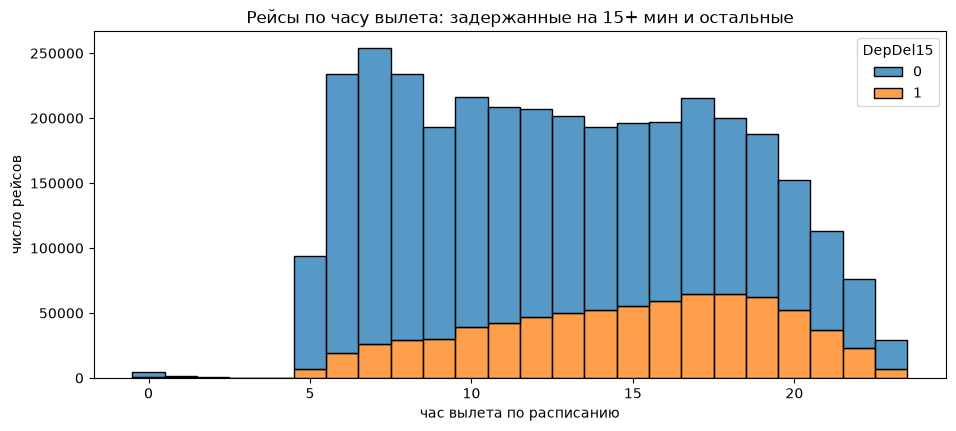

In [12]:
plt.figure(figsize=(11, 4.5))
sns.histplot(data=df, x="DepHour", hue="DepDel15", discrete=True, multiple="stack")
plt.title("Рейсы по часу вылета: задержанные на 15+ мин и остальные")
plt.xlabel("час вылета по расписанию")
plt.ylabel("число рейсов")
plt.show()

**Вывод:** доля задержанных вылетов растёт в течение дня почти монотонно: утром (5–7 ч) задерживается ~8% рейсов, вечером (18–21 ч) — 32–34%.
Задержки накапливаются: самолёт, опоздавший утром, везёт опоздание на все следующие рейсы дня. Час вылета — самый сильный из признаков, известных заранее.

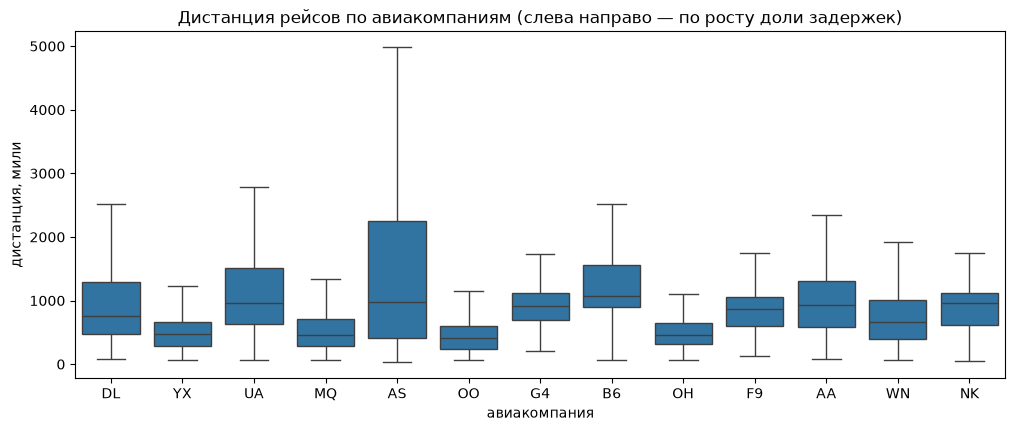

In [13]:
order = df.groupby("Reporting_Airline").DepDel15.mean().sort_values().index
plt.figure(figsize=(12, 4.5))
sns.boxplot(data=df, x="Reporting_Airline", y="Distance", order=order, showfliers=False)
plt.title("Дистанция рейсов по авиакомпаниям (слева направо — по росту доли задержек)")
plt.xlabel("авиакомпания")
plt.ylabel("дистанция, мили")
plt.show()

**Вывод:** дистанция с задержками не связана. Региональные перевозчики с короткими рейсами (YX, MQ, OO — медиана 410–480 миль) среди самых пунктуальных, а OH с такой же дистанцией (453 мили) — среди опаздывающих; дальнемагистральные AS и B6 тоже оказались по разные стороны.
Зато сама авиакомпания различает сильно: от 17% задержек у DL до 35% у NK.

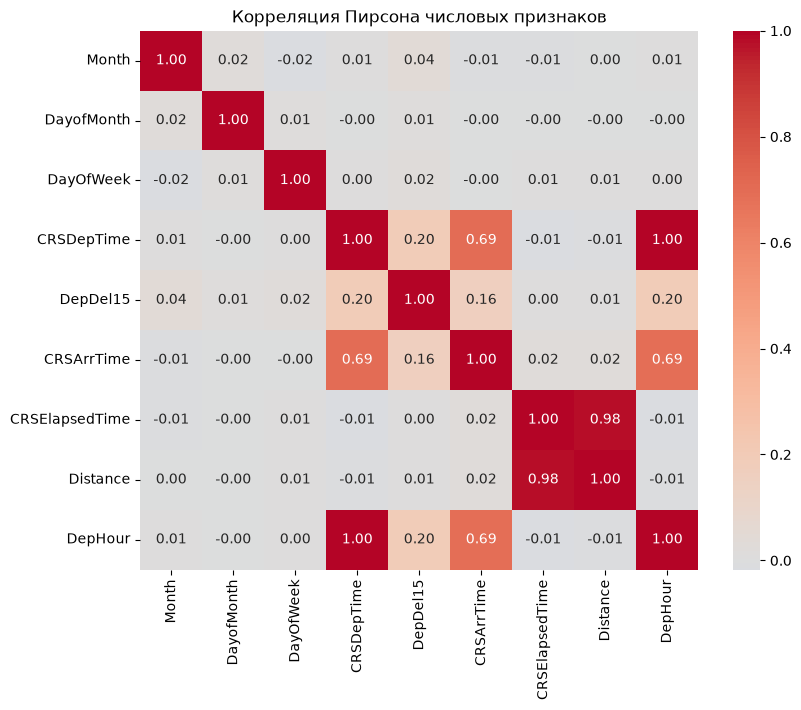

In [14]:
num = df.select_dtypes("number")
plt.figure(figsize=(9, 7))
sns.heatmap(num.corr(method="pearson"), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция Пирсона числовых признаков")
plt.show()

**Вывод:** с таргетом `DepDel15` сильнее всего связаны время вылета (`DepHour`, `CRSDepTime` — 0.20) и время прилёта по расписанию (0.16); месяц даёт 0.04, дистанция, время в пути и день недели не связаны вовсе (≤0.02).
Есть дубли: `DepHour` и `CRSDepTime` коррелируют на 1.00, `Distance` и `CRSElapsedTime` — на 0.98, для линейных моделей из каждой пары стоит оставить один признак.
Корреляция Пирсона видит только линейную связь числовых колонок — авиакомпании и аэропорты, судя по графику выше, важны, но в матрицу не попадают.

## 5. Финальный экспорт

In [15]:
assert df.isna().sum().sum() == 0
df.to_csv("flights_2026_clean.csv", index=False)
df.shape

(3412279, 15)